In [7]:
import torch
from torch.nn.functional import conv2d, conv3d
import numpy as np
import matplotlib.pyplot as plt
from scipy.ndimage import convolve, generate_binary_structure

#torch.set_default_device(device='cuda')
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
device

device(type='cuda')

Lo que ahora quiero hacer es poder hacer varias simulaciones en N dimensiones en paralelo por lo que voy a apilar lattices en un mismo tensor

In [20]:
T = 3 # K
kB = 1 # J/K

N_lattices = 3
dim_lattices = [10, 10] # todas las lattices generadas deben tener misma dim para correr en paralelo
up_spins = [0.75, 0.5, 0.25]
steps = 1000



In [ ]:
def createLattices(N_lattices, dim_lattices, up_spins, repetable):
    lattices_list = [] # sublistas: modelos [dim1, dim2, dim3, fracción spin up inicial]
    for j in range(0, N_lattices, 1):
        dim_lat = dim_lattices.copy()
        dim_lat.append(up_spins[j])
        lattices_list.append(dim_lat)

    lattices = []
    for dims in lattices_list:
        ups = dims.pop()
        lattice = np.random.choice([1, -1], size = tuple(dims), p=[ups, 1-ups])
        lattices.append(lattice)
    lattices = torch.tensor(np.array(lattices)).to(device)
    lattices = lattices.unsqueeze(1)  # (Nº redes, 1 canal, altura, anchura) para que fucnione conv2d
    
    return lattices

lattices = createLattices(N_lattices, dim_lattices, up_spins, repetable=True)
print('Lattices shape: ', lattices.shape)
lattices

Lattices shape:  torch.Size([3, 1, 10, 10])


tensor([[[[ 1,  1,  1,  1, -1,  1,  1,  1,  1,  1],
          [-1,  1, -1, -1,  1,  1,  1,  1,  1,  1],
          [ 1,  1,  1, -1,  1,  1,  1,  1,  1,  1],
          [ 1, -1,  1,  1,  1,  1,  1,  1,  1, -1],
          [-1,  1, -1,  1,  1,  1, -1,  1, -1, -1],
          [-1,  1,  1,  1,  1,  1,  1, -1,  1,  1],
          [ 1, -1,  1,  1, -1,  1, -1, -1, -1, -1],
          [ 1,  1,  1,  1,  1,  1, -1,  1, -1,  1],
          [ 1,  1,  1,  1,  1,  1,  1,  1,  1, -1],
          [ 1,  1, -1, -1,  1,  1, -1,  1,  1, -1]]],


        [[[ 1, -1,  1,  1, -1, -1, -1, -1,  1,  1],
          [-1,  1, -1, -1,  1, -1, -1, -1,  1,  1],
          [ 1, -1,  1, -1,  1,  1,  1,  1, -1,  1],
          [ 1, -1, -1,  1, -1,  1, -1,  1,  1, -1],
          [-1,  1, -1, -1, -1, -1, -1,  1, -1, -1],
          [-1,  1,  1,  1, -1,  1,  1, -1,  1, -1],
          [-1, -1,  1,  1, -1,  1, -1, -1, -1, -1],
          [ 1,  1,  1, -1,  1, -1, -1, -1, -1,  1],
          [ 1,  1, -1,  1,  1,  1, -1,  1, -1, -1],
        

In [10]:
def getEnergyLattice(lattices, J=1): # nos devuevle tensor de shape igual que lattices donde cada elemento es la energía calcualda con sus vecinos
    mask2d = torch.zeros((3, 3), dtype=bool).to(device)
    mask2d[0, 1] = mask2d[2, 1] = mask2d[1, 0] = mask2d[1, 2] = 1
    mask2d = mask2d.unsqueeze(0).unsqueeze(0).to(device) # (1 salida, 1 canal, altura, anchura)
    Etotal = -J*lattices*conv2d(input=lattices.to(torch.float32), weight=mask2d.to(torch.float32), padding='same') #padding para que no se coma el borde
    return Etotal
    
def getEnergyScalar(lattices):
    return getEnergyLattice(lattices).sum(axis=(2, 3)).squeeze()

def getDeltaEnergyLattice(lattices): # resultado de cálculo de la diferencia de energía al cambiar 1 spin
    return -2*getEnergyLattice(lattices)


No vamos a cambiar un solo spin a la vez, creamos una malla donde spines separados por 1 átomo se cambien y localmente se decida si mantener el cambio o no. Solo hay 4 posibels mallas que generar, las que empiecen en el átomo (0, 0), (0, 1), (1, 0) y (1, 1). Con esas 4 barres todo el espacio.

In [11]:
def MetropolisStep(lattices, betas, J=1):
    i, j = np.random.randint(low = 0, high = 2), np.random.randint(low = 0, high = 2) # 0 o 1
    deltaE = getDeltaEnergyLattice(lattices)[:, :, i::2, j::2] # nos quedamos con las mallas seleccionadas. espacialmente tenemos la mitad de elementos al ahcer esto
    #creamos máscara que aplique metrópolis. de primeras nos quedamos siempre con las variaciones que reducen al energía.
    mask = (deltaE<0) | (deltaE>=0)*(torch.rand(deltaE.shape).to(device) < torch.exp(-betas*deltaE))
    sub_lattice = lattices[:, :, i::2, j::2]
    sub_lattice[mask] *= -1
    lattices[:, :, i::2, j::2] = sub_lattice
    energies = getEnergyScalar(lattices)
    spins = lattices.sum(axis=(-1, -2))/np.prod(dim_lattices) #valor medio del spin
    return lattices, energies, spins


betas = (1 / (kB * T)) * torch.ones(N_lattices, device=device)
betas = betas.view(-1, 1, 1, 1)


lats_list = []
energies_list = []
spins_list = []

for step in range(0, steps, 1):
    lat, ene, spin = MetropolisStep(lattices, betas)
    lats_list.append(lat)
    energies_list.append(ene)
    spins_list.append(spin)
    if step % 10000 == 0:
        print(f'Step: {step}/{steps}')


Step: 0/1000


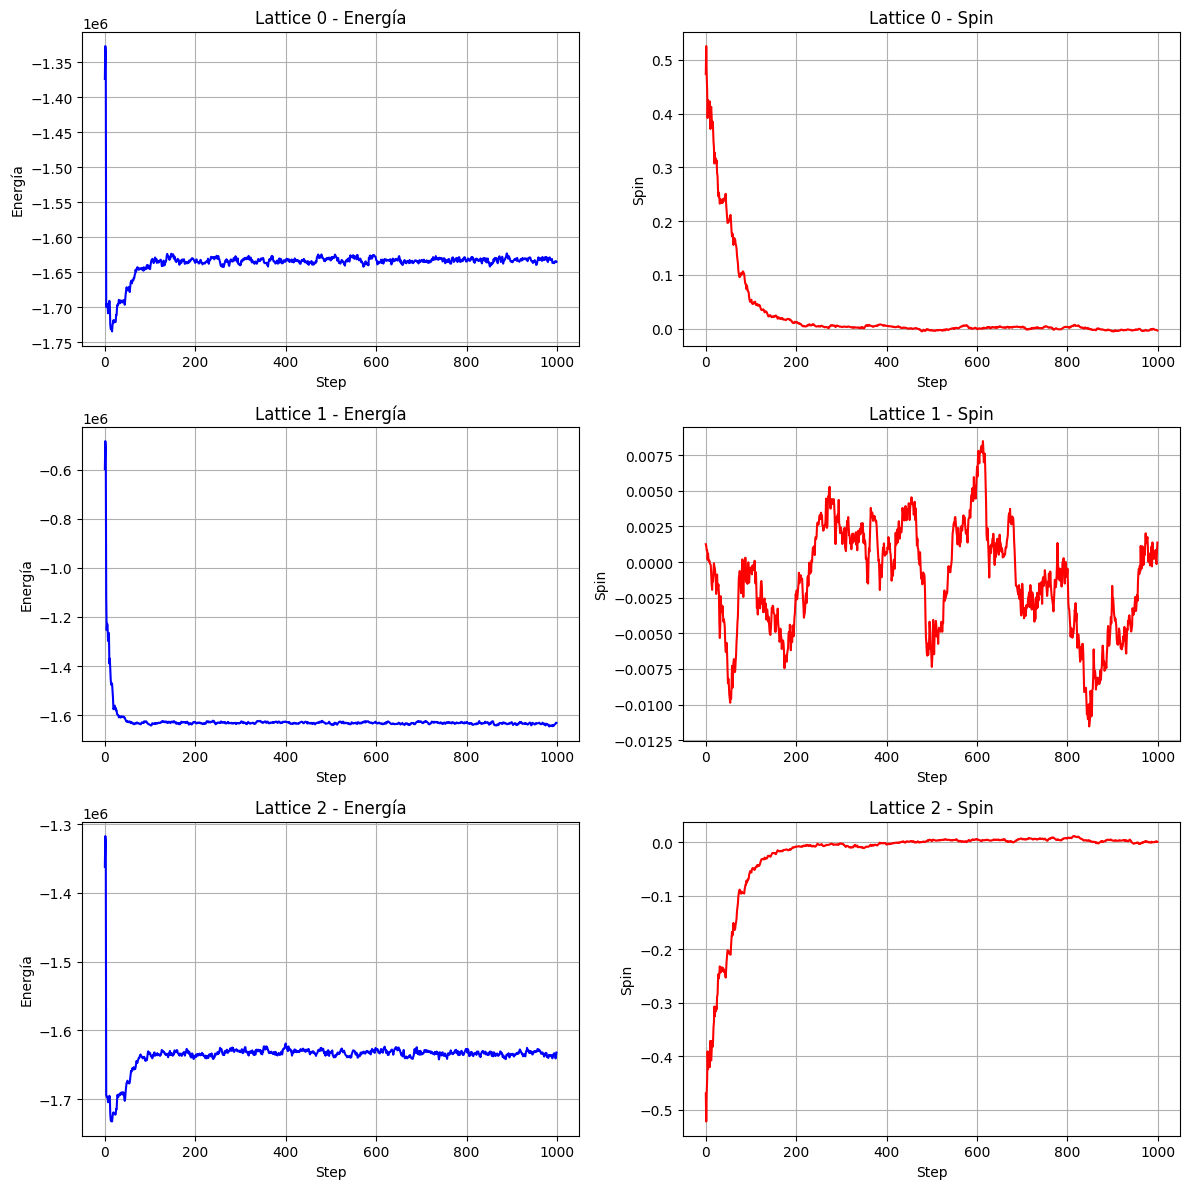

In [12]:
import matplotlib.pyplot as plt
import torch
import numpy as np

# Apilamos los tensores y hacemos squeeze para quitar dimensiones extras
energies_array = torch.stack(energies_list).squeeze().cpu()  # shape (steps, N_lattices)
spins_array = torch.stack(spins_list).squeeze().cpu()        # shape (steps, N_lattices)

# Si hay solo 1 lattice, añadimos dimensión de columnas
if energies_array.dim() == 1:
    energies_array = energies_array.unsqueeze(1)
    spins_array = spins_array.unsqueeze(1)

energies_array = energies_array.numpy()
spins_array = spins_array.numpy()

N_lattices = energies_array.shape[1]
steps = energies_array.shape[0]

# Creamos subplots
fig, axs = plt.subplots(N_lattices, 2, figsize=(12, 4*N_lattices))

# Si solo hay 1 lattice, axs no es array 2D, lo convertimos
if N_lattices == 1:
    axs = np.expand_dims(axs, axis=0)

for i in range(N_lattices):
    # Energía
    axs[i, 0].plot(np.arange(steps), energies_array[:, i], color='blue')
    axs[i, 0].set_title(f"Lattice {i} - Energía")
    axs[i, 0].set_xlabel("Step")
    axs[i, 0].set_ylabel("Energía")
    axs[i, 0].grid(True)
    
    # Spin
    axs[i, 1].plot(np.arange(steps), spins_array[:, i], color='red')
    axs[i, 1].set_title(f"Lattice {i} - Spin")
    axs[i, 1].set_xlabel("Step")
    axs[i, 1].set_ylabel("Spin")
    axs[i, 1].grid(True)

plt.tight_layout()
plt.show()

# Energía y Spin vs temperatura


In [ ]:
Ts = np.arange(0, 5, 0.5)

lattices075=createLattices(N_lattices=len(Ts))

array([0. , 0.5, 1. , 1.5, 2. , 2.5, 3. , 3.5, 4. , 4.5])